import and loading dataset

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
cc = pd.read_csv('../data/raw/creditcard.csv')

print("Fraud shape:", fraud.shape)
print("IP-Country shape:", ip_country.shape)
print("Credit card shape:", cc.shape)

Fraud shape: (151112, 11)
IP-Country shape: (138846, 3)
Credit card shape: (284807, 31)


fix date-time cols

In [16]:
fraud["signup_time"] = pd.to_datetime(fraud["signup_time"])
fraud["purchase_time"] = pd.to_datetime(fraud["purchase_time"])

Geolocation: IP Address → Country
ip to integer

In [27]:
fraud['ip_int'] = fraud['ip_address'].astype(np.int64)

print("Sample ip_int values:", fraud['ip_int'].head())
print("ip_int range:", fraud['ip_int'].min(), "→", fraud['ip_int'].max())
print("ip_country range:", ip_country['lower_bound_ip_address'].min(
), "→", ip_country['lower_bound_ip_address'].max())

Sample ip_int values: 0     732758368
1     350311387
2    2621473820
3    3840542443
4     415583117
Name: ip_int, dtype: int64
ip_int range: 52093 → 4294850499
ip_country range: 16777216 → 3758096128


range based merge

In [28]:
fraud_sorted = fraud.dropna(subset=['ip_int']).copy()
fraud_sorted['ip_int'] = fraud_sorted['ip_int'].astype(np.int64)

ip_country['lower_bound_ip_address'] = ip_country['lower_bound_ip_address'].astype(
    np.int64)
ip_country['upper_bound_ip_address'] = ip_country['upper_bound_ip_address'].astype(
    np.int64)

ip_country_sorted = ip_country.sort_values(
    'lower_bound_ip_address').reset_index(drop=True)
fraud_sorted = fraud_sorted.sort_values('ip_int').reset_index(drop=True)

merged = pd.merge_asof(
    fraud_sorted,
    ip_country_sorted,
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

merged['country'] = np.where(
    merged['ip_int'] <= merged['upper_bound_ip_address'],
    merged['country'],
    'Unknown'
)

print("Merged shape:", merged.shape)
print(merged['country'].value_counts().head(10))

Merged shape: (151112, 15)
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64


fraud rate part country

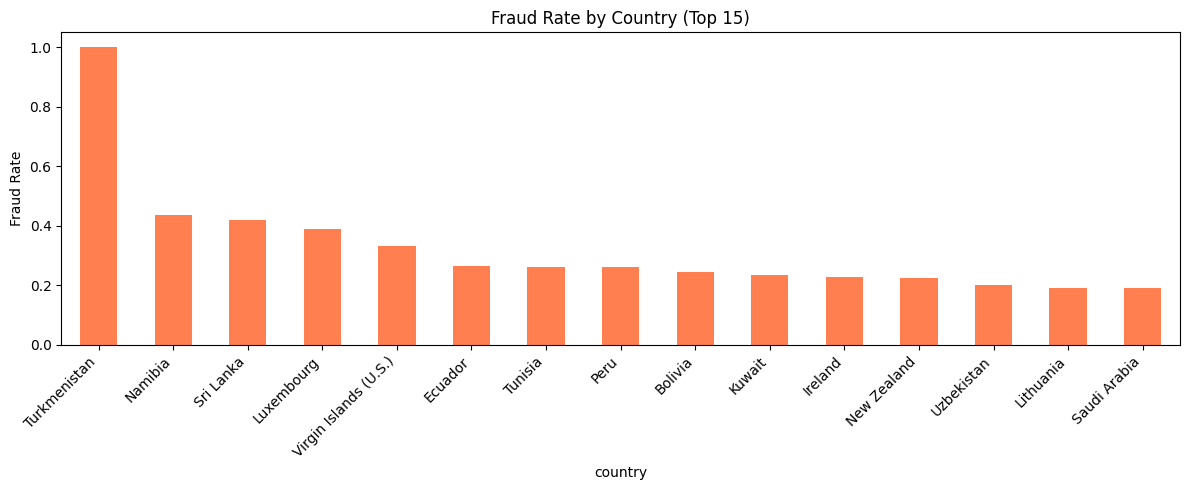

In [32]:
top_countries = merged.groupby(
    "country")['class'].mean().sort_values(ascending=False).head(15)
top_countries.plot(kind='bar', figsize=(12, 5), color='coral')
plt.title('Fraud Rate by Country (Top 15)')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

time features

In [33]:
merged['hour_of_day'] = merged['purchase_time'].dt.hour
merged['day_of_week'] = merged['purchase_time'].dt.dayofweek
merged['time_since_signup'] = (
    merged['purchase_time'] - merged['signup_time']
).dt.total_seconds() / 3600  

plot time features vs fraud

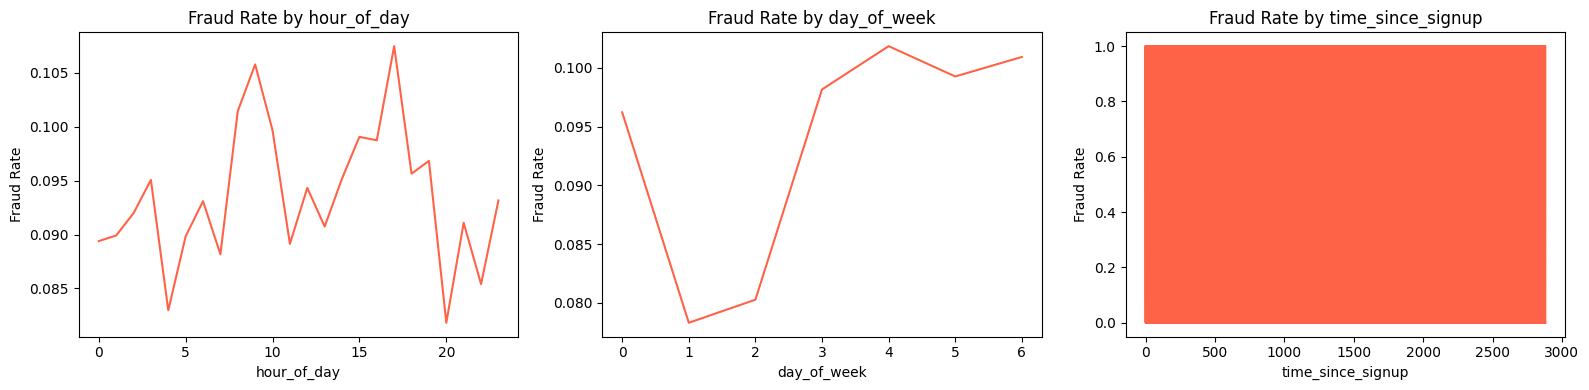

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['hour_of_day', 'day_of_week', 'time_since_signup']):
    merged.groupby(col)['class'].mean().plot(ax=ax, color='tomato')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

Transaction Velocity Features
Transaction count per user

In [35]:
user_tx_count = merged.groupby('user_id')['purchase_time'].transform('count')
merged['user_tx_count'] = user_tx_count

device reuse count

In [36]:
device_tx_count = merged.groupby(
    'device_id')['purchase_time'].transform('count')
merged['device_tx_count'] = device_tx_count

Encoding Categorical Features & Scaling Numerics
Drop unneeded columns, encode

In [37]:
drop_cols = ['user_id', 'signup_time', 'purchase_time', 'ip_address',
             'ip_int', 'lower_bound_ip_address', 'upper_bound_ip_address', 'device_id']

fraud_clean = merged.drop(columns=drop_cols, errors='ignore')

fraud_clean = pd.get_dummies(fraud_clean, columns=['source', 'browser', 'sex', 'country'],
                             drop_first=False)
fraud_clean.head()

,purchase_value,age,class,hour_of_day,day_of_week,time_since_signup,user_tx_count,device_tx_count,source_Ads,source_Direct,...,country_Unknown,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,46,36,0,10,6,489.726111,1,1,False,True,...,True,False,False,False,False,False,False,False,False,False
1,33,30,0,17,4,301.339722,1,1,True,False,...,True,False,False,False,False,False,False,False,False,False
2,33,32,0,8,1,208.144444,1,1,False,True,...,True,False,False,False,False,False,False,False,False,False
3,33,40,0,21,3,2065.176111,1,1,True,False,...,True,False,False,False,False,False,False,False,False,False
4,55,38,0,7,6,391.005278,1,1,True,False,...,True,False,False,False,False,False,False,False,False,False


scale numeric features

In [38]:
num_cols = ['purchase_value', 'age', 'hour_of_day', 'day_of_week',
            'time_since_signup', 'user_tx_count', 'device_tx_count']

scaler = StandardScaler()
fraud_clean[num_cols] = scaler.fit_transform(fraud_clean[num_cols])

train/test split

In [39]:
X = fraud_clean.drop(columns=['class'])
y = fraud_clean['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train class dist:\n", y_train.value_counts())
print("Test class dist:\n", y_test.value_counts())

Train class dist:
 class
0    109568
1     11321
Name: count, dtype: int64
Test class dist:
 class
0    27393
1     2830
Name: count, dtype: int64


apply SMOTE on traning only

In [41]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 109568, 1: 11321}
After SMOTE:  {0: 109568, 1: 109568}


visualization before and after

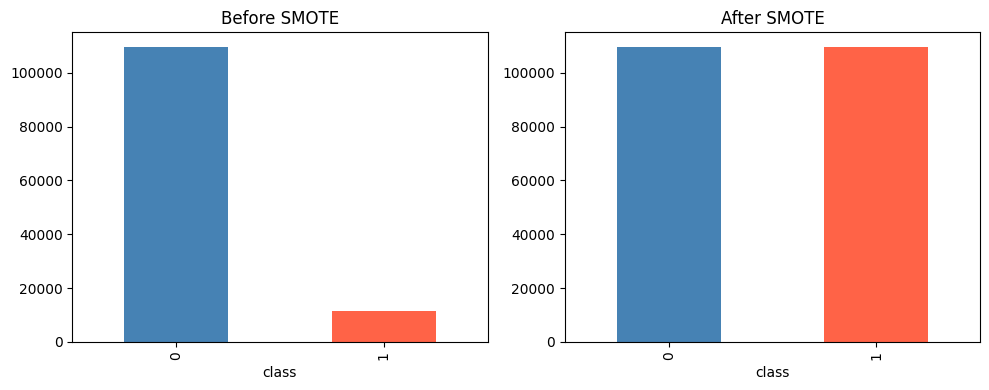

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Before SMOTE')
pd.Series(y_train_res).value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('After SMOTE')
plt.tight_layout()
plt.show()

and then finally saving

In [43]:
import os
os.makedirs('../data/processed', exist_ok=True)
X_train_res.to_csv('../data/processed/fraud_X_train.csv', index=False)
X_test.to_csv('../data/processed/fraud_X_test.csv', index=False)
pd.Series(y_train_res, name='class').to_csv(
    '../data/processed/fraud_y_train.csv', index=False)
y_test.to_csv('../data/processed/fraud_y_test.csv', index=False)

X_cc = cc.drop(columns=['Class'])
y_cc = cc['Class']

X_cc_train, X_cc_test, y_cc_train, y_cc_test = train_test_split(
    X_cc, y_cc, test_size=0.2, stratify=y_cc, random_state=42
)

scaler_cc = StandardScaler()
X_cc_train_scaled = scaler_cc.fit_transform(X_cc_train)
X_cc_test_scaled = scaler_cc.transform(X_cc_test)

sm_cc = SMOTE(random_state=42)
X_cc_train_res, y_cc_train_res = sm_cc.fit_resample(
    X_cc_train_scaled, y_cc_train)

pd.DataFrame(X_cc_train_res, columns=X_cc.columns).to_csv(
    '../data/processed/cc_X_train.csv', index=False)
pd.DataFrame(X_cc_test_scaled, columns=X_cc.columns).to_csv(
    '../data/processed/cc_X_test.csv', index=False)
pd.Series(y_cc_train_res, name='Class').to_csv(
    '../data/processed/cc_y_train.csv', index=False)
y_cc_test.to_csv('../data/processed/cc_y_test.csv', index=False)

print("All processed files saved.")

All processed files saved.
